In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output


In [4]:
one = np.array([[1., 0.],[0.,1.]])
pauli_1 = np.array([[0.,1.],[1.,0.]])
pauli_2 = np.array([[0., 0-1j],[0 +1j, 0.]])
pauli_3 = np.array([[1.,0.],[0., -1.]])
plus = (1/2 * (pauli_1 + 1.j * pauli_2)).real
minus = (1/2 * (pauli_1 - 1.j * pauli_2)).real

In [5]:
#Hamiltonian
number_of_qubits = 10
m = 0.1

def Get_H(m):
    res_XY = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_mass = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_iter = torch.zeros(2**number_of_qubits, 2**number_of_qubits)


    # XY term
    first = one
    for i in range(1,number_of_qubits):
        #print(i)
        first = one
        second = one
        for j in range(1, number_of_qubits -i-1):
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        if i != number_of_qubits - 1 :
            first = TensorProduct(minus, first)
            first = TensorProduct(plus, first)
            second = TensorProduct(plus, second)
            second = TensorProduct(minus, second)
        else:
            first = TensorProduct(plus, minus)
            second = TensorProduct(minus, plus)
        for j in range(1,i):
            #print("uu")
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        #print(c.size())
        res_XY += torch.from_numpy(first + second)

    #print(res_XY)

    # mass term
    for i in range(1, number_of_qubits + 1):
        mass = one
        for j in range(1, number_of_qubits - i):
            mass = TensorProduct(one, mass)
        if i == number_of_qubits:
            mass = pauli_3
        else:
            mass = TensorProduct(pauli_3, mass)
        for j in range(1, i):
            mass = TensorProduct(one, mass)
    
        res_mass += (-1)**i * (torch.from_numpy(mass))
    
       
    #print(res_mass)

    # iteraction term
    for i in range(1,number_of_qubits ):
        res_ite = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        res_ones = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        for j in range(1, i + 1):
        
            ite = one
        
            for k in range(1, number_of_qubits - j):
                ite = TensorProduct(one, ite)
            if j == number_of_qubits:
                ite = pauli_3
            else:
                ite = TensorProduct(pauli_3, ite)
            for k in range(1, j):
                ite = TensorProduct(one, ite)
            res_ite += (torch.from_numpy(ite)) 
            ones = one
        
            for k in range(1,number_of_qubits):
                ones = TensorProduct(one, ones)
            res_ones += (-1)**j*(torch.from_numpy(ones))
        res_iter += torch.matmul(res_ones + res_ite, res_ones + res_ite)   
    
    
    return 1/4*res_iter + res_XY + m/2*res_mass 
H = Get_H(m)
I = torch.zeros(2**number_of_qubits,2**number_of_qubits)
for i in range(2**number_of_qubits):
    I[i][i] = 1.579100
#H = H +I
print(H)

tensor([[60.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000, 59.9000,  1.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  1.0000, 53.1000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ..., 75.9000,  1.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  1.0000, 85.1000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 85.0000]])


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [7]:
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


In [8]:
#работает!!!

def matrix_element_iter_new(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    C = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1).to(device)
    
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2       

    C[j,j] = -(batch_new[j]*coef).sum(dim = 1)
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2).to(device)
    
    for i in range(0,number_of_qubits-1):
        s = torch.zeros(batch_size).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m, coef_2[m-1])
            s += coef_2[m - 1]*batch_new[:,m]
            #print(s)
        #print(s)    
        C[j,j] += batch_new[j,i]*s[j]
       
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I    
    return (C + One)/4
                
            
def matrix_element_xy(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    
    place = torch.zeros(number_of_qubits -1,2)
    C = torch.zeros(batch_size, batch_size)
    
    for i in range(number_of_qubits-1):
        place[i][0]= i
        place[i][1] = i+1
    outt = torch.arange(batch_size)
    for i in outt:
        for j in outt:
            true = (torch.nonzero(batch_new[i] != batch_new[j])).reshape(-1)
            if (true.shape[0] == 2) and ((true == place).prod(dim = 1).sum()):
                C[i,j] = 1 -batch_new[i,true[0]]*batch_new[i,true[1]]
    return C/2

def matrix_element_m(batch):

    batch_new = torch.clone(batch)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    
    t = torch.arange(0,number_of_qubits,1).to(device)
    
    batch_new[:,t] *= (-1)**(t+1)
    
    M = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1)
    M[j,j] = -batch_new.sum(dim = 1)
        #N+= M
    return m/2*M

def matrix_element_xy_new_7(batch):
    batch_new = torch.clone(batch)
    #print(batch_new.device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    res = batch_new.unsqueeze(1) != batch_new
    
    place = torch.zeros(number_of_qubits -1,number_of_qubits).to(device)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][i]= 1
        place[i][i+1] = 1
        true = torch.nonzero((res == place[i]).prod(dim = 2)==1)
        ress = batch_new[true[:,0],i]*batch_new[true[:,0],i+1]
        C[true[:,0], true[:,1]] = 1 - ress
    return C/2

def matrix(batch):               
    return  matrix_element_iter_new(batch) + matrix_element_xy_new_7(batch) + matrix_element_m(batch)

In [9]:
def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)

In [8]:
class MaskedLinear(nn.Linear):
    def __init__(self, in_channels, out_channels, bias, exclusive):
        super(MaskedLinear, self).__init__(in_channels, out_channels,
                                           bias)
        self.in_channels = in_channels
        self.out_channels = out_channels
        #self.n = n
        self.exclusive = exclusive

        self.register_buffer('mask', torch.ones([self.in_channels]*2))
        if self.exclusive:
            self.mask = 1 - torch.triu(self.mask)
        else:
            self.mask = torch.tril(self.mask)
        #self.mask = torch.cat([self.mask] * in_channels, dim=1)
        #self.mask = torch.cat([self.mask] * out_channels, dim=0)
        self.weight.data *= self.mask

        # Correction to Xavier initialization
        self.weight.data *= torch.sqrt(self.mask.numel() / self.mask.sum())

    def forward(self, x):
        return nn.functional.linear(x, self.mask * self.weight, self.bias)

    def extra_repr(self):
        return (super(MaskedLinear, self).extra_repr() +
                ', exclusive={exclusive}'.format(**self.__dict__))

In [ ]:
class Net_auto(nn.Module):
    
    lr = 0.01 
    N_epochs = 20000
    
    def __init__(self):
        super(Net_auto,self).__init__()
        self.Linear0 = MaskedLinear(number_of_qubits, number_of_qubits, bias = False, exclusive=True)
        self.Linear1 = MaskedLinear(number_of_qubits, number_of_qubits, bias = False, exclusive=False)
        self.Linear2 = MaskedLinear(number_of_qubits, number_of_qubits, bias = False, exclusive=False)
        self.Linear3 = MaskedLinear(number_of_qubits, number_of_qubits, bias = False, exclusive=False)
        self.Linear4 = MaskedLinear(number_of_qubits, number_of_qubits, bias = False, exclusive=False)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.bn0 = nn.BatchNorm1d(10)
    
    def forward(self,a):
        x = self.Linear0(a)
        x = self.tanh(x)
        #x[a == 1] = self.tanh(x[a == 1])
        #x[a == 0] = torch.sqrt(1 - self.tanh(x[a == 0])**2)
        x = self.bn0(x)
        #print(x)

        x = self.Linear1(x)
        x = self.tanh(x)
        #x[a == 1] = self.tanh(x[a == 1])
        #x[a == 0] = torch.sqrt(1 - self.tanh(x[a == 0])**2)
        #x = self.sigmoid(x)
        x = self.bn0(x)

        x = self.Linear2(x)
        x = self.tanh(x)
        x = self.bn0(x)

        x = self.Linear3(x)
        x = self.tanh(x)
        x = self.bn0(x)

        x = self.Linear4(x)
        x[a == 1] = self.tanh(x[a == 1])
        x[a == 0] = torch.sqrt(torch.abs(1 - self.tanh(x[a == 0])**2))
        #print(x)
        #x = self.sigmoid(x)
        #x = self.tanh(x)
        
        return x
    
    def loss_classic(self,inp):
        res = torch.matmul(inp, torch.matmul(H, torch.transpose(inp, 0, 1)))
        return res
    
    def loss(self,batch):
        out, num= torch.unique(batch, return_counts = True,dim = 0)
        psi = new(out)
        psi = psi.prod(dim =1)
        #print(psi, psi.norm())
        M = matrix(out)
        E = torch.matmul(torch.transpose(psi.view(out.shape[0],1), 0, 1), torch.matmul(M, psi))
        return E
    
    
    def optimize(self,inp):
        optimizer = torch.optim.Adam(self.parameters(), lr = self.lr, betas=(0.9, 0.999))###
        #optimizer = torch.optim.SGD(self.parameters(), self.lr, momentum= 0.9) 
        distance = []
        count = 0
        #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5000,20000], gamma=0.1)
        for i in tqdm(range(self.N_epochs)): #tqdm показывет процесс выполенения в процентах
            optimizer.zero_grad()
            count += 1
            loss_curr = self.loss(inp)
            #scheduler.step()
            if math.isnan(loss_curr):
                param = list(new.parameters())
                print(param)
                print(i)
                print(new(inp))
                break
            if i == self.N_epochs - 1:
                print(loss_curr)
                
            loss_curr.backward()
            #print(new.Linear0.weight.grad.norm(), 'grad, linear0, weight before clip')
            #print(new.Linear1.weight.grad.norm(), 'grad, linear2, weight')
            nn.utils.clip_grad_value_(new.parameters(), clip_value=1.0)
            #print(new.Linear0.weight.grad.norm(), 'grad, linear0, weight after clip')
            #print(new.Linear1.weight.grad.norm(), 'grad, linear2, weight')
            optimizer.step() # parameter update
            distance.append(loss_curr.view(1).detach().cpu().numpy())# To stop a tensor from tracking history, you can call .detach() 
            #to detach it from the computation history, and to prevent future computation from being tracked.
            
            if count == 1000:
                clear_output()
                plt.plot(distance)
                plt.show()
                print(loss_curr)
                print(new(inp))
                print('Epoch-{0} lr: {1}'.format(i, optimizer.param_groups[0]['lr']))
                count = 0
        return distance   

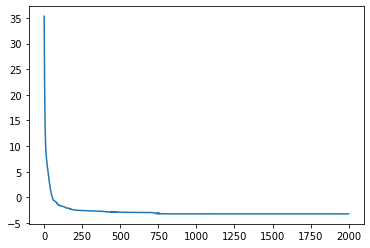





 10%|█         | 2003/20000 [01:03<12:21, 24.28it/s]

tensor([-3.2287], device='cuda:0', grad_fn=<MvBackward>)
tensor([[ 9.6351e-01,  1.1519e-02,  9.3084e-01,  ...,  8.0772e-02,
          9.0289e-01,  9.7656e-04],
        [ 9.6351e-01,  1.1519e-02,  9.3084e-01,  ...,  8.0772e-02,
          9.0289e-01, -1.0000e+00],
        [ 9.6351e-01,  1.1519e-02,  9.3084e-01,  ...,  8.0772e-02,
          4.2987e-01,  1.1728e-01],
        ...,
        [-2.6768e-01, -2.3491e-04,  4.4843e-02,  ...,  9.4908e-01,
          9.3511e-01,  9.9892e-01],
        [-2.6768e-01, -2.3491e-04,  4.4843e-02,  ...,  9.4908e-01,
         -3.5436e-01,  4.6396e-02],
        [-2.6768e-01, -2.3491e-04,  4.4843e-02,  ...,  9.4908e-01,
         -3.5436e-01,  9.9892e-01]], device='cuda:0',
       grad_fn=<IndexPutBackward>)
Epoch-1999 lr: 0.01






 10%|█         | 2007/20000 [01:03<11:33, 25.95it/s]



 10%|█         | 2011/20000 [01:03<10:48, 27.75it/s]



 10%|█         | 2015/20000 [01:03<10:21, 28.95it/s]



 10%|█         | 2019/20000 [01:03<10:00, 29.95it/s]



 10%|█         | 2023/20000 [01:03<09:48, 30.54it/s]



 10%|█         | 2027/20000 [01:03<09:35, 31.24it/s]



 10%|█         | 2031/20000 [01:03<09:27, 31.69it/s]



 10%|█         | 2035/20000 [01:04<09:25, 31.80it/s]



 10%|█         | 2039/20000 [01:04<09:32, 31.36it/s]



 10%|█         | 2043/20000 [01:04<09:33, 31.30it/s]



 10%|█         | 2047/20000 [01:04<09:27, 31.62it/s]



 10%|█         | 2051/20000 [01:04<09:30, 31.47it/s]



 10%|█         | 2055/20000 [01:04<09:28, 31.58it/s]



 10%|█         | 2059/20000 [01:04<09:27, 31.62it/s]



 10%|█         | 2063/20000 [01:04<09:23, 31.85it/s]



 10%|█         | 2067/20000 [01:05<09:24, 31.76it/s]



 10%|█         | 2071/20000 [01:05<09:25, 31.72it/s]



 10%|█         | 2075/20000 [01:05<09:30, 31

[Parameter containing:
tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]], device='cuda:0',
       requires_grad=True), Parameter containing:
tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [

NameError: ignored

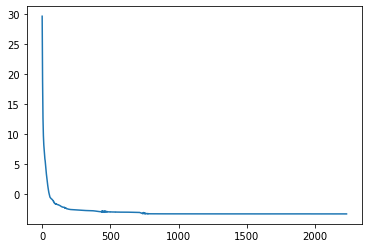

In [ ]:
new = Net_auto().to(device)
param = list(new.parameters())
#print(param)
basis2 = torch.clone(basis)
#basis2[basis2==0] =-1
batch = torch.clone(basis2).to(device)
#print(batch)
m = 0.1

dist = new.optimize(batch)
plt.plot(dist[1:])

print('exact solution ={}'.format(c))
psi = new(basis).prod(dim = 1).reshape(1,16)
res = torch.matmul(psi, torch.matmul(H, torch.transpose(psi, 0, 1)))
print('ML solution ={}'.format(res))
print('exact solution ={}'.format(new.loss_classic(new(basis).prod(dim = 1))))

basis_gpu = basis.to(device)
H_gpu = H.to(device)
Psi = net(basis_gpu)/net(basis_gpu).norm()
print(torch.matmul(torch.transpose(Psi, 0, 1), torch.matmul(H_gpu, Psi)), "jjj")

In [9]:
torch.set_printoptions(precision=5)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[1]
print(c, m)
#print(net.loss(net(basis)/net(basis).norm()), 'loss через H')
print(torch.sort(eig_values))

tensor(-4.40245) tensor(124)
torch.return_types.sort(
values=tensor([-4.40245, -3.95188, -2.58923,  ..., 76.14705, 85.00000, 85.20814]),
indices=tensor([ 124,  125,  181,  ...,   35, 1023,    0]))


In [ ]:
class Net_auto_ln(nn.Module):
    
    lr = 0.0001 
    N_epochs = 100000
    
    def __init__(self):
        super(Net_auto_ln,self).__init__()
        self.Linear0 = MaskedLinear(number_of_qubits, number_of_qubits, bias = False, exclusive=True)
        self.Linear1 = MaskedLinear(number_of_qubits, number_of_qubits, bias = False, exclusive=False)
        self.Linear2 = MaskedLinear(number_of_qubits, number_of_qubits, bias = False, exclusive=False)
        self.Linear7 = MaskedLinear(number_of_qubits, number_of_qubits, bias = False, exclusive=False)
        self.Linear4 = nn.Linear(number_of_qubits, 50)
        self.Linear5 = nn.Linear(50,1)
        self.Linear6 = nn.Linear(number_of_qubits,2)
        self.epsilon = 0.00001
         
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.bn0 = nn.BatchNorm1d(10)
        self.softmax = nn.Softmax(dim = 1)
        self.lnsigmoid = nn.LogSigmoid()
    
    def forward(self,a):
        x = self.Linear0(a)
        #x = self.sigmoid(x)
        x = self.tanh(x)
        #x = self.relu(x)
        #x = self.softmax(x)
        #x[a == 1] = self.lnsigmoid(x[a == 1])
        #x[a == 0] = torch.log(1 - self.sigmoid(x[a==0]))
        x = self.bn0(x)
        
        
        x = self.Linear1(x)
        x = self.tanh(x)
        #x = self.sigmoid(x)
        #x[a == 1] = self.lnsigmoid(x[a == 1])
        #x[a == 0] = torch.log(1 - self.sigmoid(x[a==0]))
        x = self.bn0(x)

        x = self.Linear7(x)
        x = self.tanh(x)
        #x = self.sigmoid(x)
        #x[a == 1] = self.lnsigmoid(x[a == 1])
        #x[a == 0] = torch.log(1 - self.sigmoid(x[a==0]))
        x = self.bn0(x)
        
        x = self.Linear2(x)
        x[a == 1] = self.lnsigmoid(x[a == 1])
        x[a == 0] = torch.log(torch.abs(1 - self.sigmoid(x[a==0])))
        
        y = self.Linear4(a)
        y = self.sigmoid(y)*2*math.pi
        y = self.Linear5(y)
        y = self.sigmoid(y)*2*math.pi

        return x,y
    
    
    def loss_classic(self,batch):
        out, num= torch.unique(batch, return_counts = True,dim = 0)
        psi, phase = new(out)
        
        psi = psi.sum(dim = 1)
        psi = torch.exp(psi)
        psi = torch.sqrt(psi)
        #print(psi.norm())
        
        psi_real = psi *torch.cos(phase.view(psi.shape[0])) 
        psi_imag = psi *torch.sin(phase.view(psi.shape[0]))

        #M = matrix(out)
        E = torch.matmul(torch.transpose(psi_real.view(out.shape[0],1), 0, 1), torch.matmul(H, psi_real)) + torch.matmul(torch.transpose(psi_imag.view(out.shape[0],1), 0, 1), torch.matmul(H, psi_imag))
        return E
    
    def loss(self,batch):
        out, num= torch.unique(batch, return_counts = True,dim = 0)
        psi, phase = new(out)
        
        psi = psi.sum(dim = 1)
        psi = torch.exp(psi)
        psi = torch.sqrt(psi)
        #print(psi.norm())
        
        psi_real = psi *torch.cos(phase.view(psi.shape[0])) 
        psi_imag = psi *torch.sin(phase.view(psi.shape[0]))

        M = matrix(out)
        E = torch.matmul(torch.transpose(psi_real.view(out.shape[0],1), 0, 1), torch.matmul(M, psi_real)) + torch.matmul(torch.transpose(psi_imag.view(out.shape[0],1), 0, 1), torch.matmul(M, psi_imag))
        #E = torch.matmul(torch.transpose(psi.view(out.shape[0],1), 0, 1), torch.matmul(M, psi))
        return E
    
    
    def optimize(self,inp):
        optimizer = torch.optim.Adam(self.parameters(), lr = self.lr, betas=(0.9, 0.999))###
        #optimizer = torch.optim.SGD(self.parameters(), self.lr, momentum= 0.9) 
        distance = []
        count = 0
        previous = 0
        #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5000,20000], gamma=0.1)
        for i in tqdm(range(self.N_epochs)): #tqdm показывет процесс выполенения в процентах
            optimizer.zero_grad()
            count += 1
            loss_curr = self.loss_classic(inp)
            #loss_curr = self.loss(inp)
            #scheduler.step()
            
            #param = list(new.parameters())
            #print(param)
            if math.isnan(loss_curr):
                param = list(new.parameters())
                print(param, 'parameters')
                print(i,'i')
                #print(new(inp))
                break
            if i == self.N_epochs - 1:
                print(loss_curr)
                
            loss_curr.backward()
            
            #print(new.Linear0.weight.grad.norm(), 'grad, linear0, weight')
            #print(new.Linear2.weight.grad.norm(), 'grad, linear2, weight')
            #print(new.Linear0.bias.grad, 'grad, lineat0, bias')
            #torch.nn.utils.clip_grad_norm_(new.parameters(), 1)
            #print(new.Linear0.weight.grad.norm(), 'grad, linear0, weight before clip')
            #print(new.Linear2.weight.grad.norm(), 'grad, linear2, weight')
            nn.utils.clip_grad_value_(new.parameters(), clip_value=1.0)
            #print(new.Linear0.weight.grad.norm(), 'grad, linear0, weight after clip')
            #print(new.Linear2.weight.grad.norm(), 'grad, linear2, weight')
            optimizer.step() # parameter update
            distance.append(loss_curr.view(1).detach().cpu().numpy())# To stop a tensor from tracking history, you can call .detach() 
            #to detach it from the computation history, and to prevent future computation from being tracked.
            
            #print(distance[-1] - previous)
            previous = distance[-1]
            if count == 1000:
                clear_output()
                plt.plot(distance)
                plt.show()
                print(loss_curr)
                #print(new(inp))
                print('Epoch-{0} lr: {1}'.format(i, optimizer.param_groups[0]['lr']))
                count = 0
        return distance   

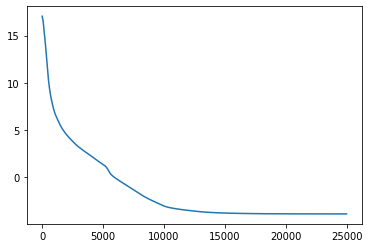










 25%|██▌       | 25004/100000 [06:06<24:41, 50.63it/s]








 25%|██▌       | 25011/100000 [06:06<22:47, 54.83it/s]

tensor([-3.85276], grad_fn=<AddBackward0>)
Epoch-24999 lr: 0.0001











 25%|██▌       | 25018/100000 [06:06<21:21, 58.51it/s]








 25%|██▌       | 25025/100000 [06:06<20:31, 60.88it/s]








 25%|██▌       | 25032/100000 [06:06<20:30, 60.91it/s]








 25%|██▌       | 25040/100000 [06:07<19:36, 63.70it/s]








 25%|██▌       | 25047/100000 [06:07<19:08, 65.24it/s]








 25%|██▌       | 25055/100000 [06:07<18:38, 67.03it/s]








 25%|██▌       | 25063/100000 [06:07<18:22, 67.99it/s]








 25%|██▌       | 25070/100000 [06:07<18:21, 68.05it/s]








 25%|██▌       | 25077/100000 [06:07<18:19, 68.17it/s]








 25%|██▌       | 25084/100000 [06:07<18:17, 68.23it/s]








 25%|██▌       | 25092/100000 [06:07<18:05, 69.01it/s]








 25%|██▌       | 25099/100000 [06:07<18:16, 68.29it/s]








 25%|██▌       | 25106/100000 [06:08<18:54, 66.00it/s]








 25%|██▌       | 25113/100000 [06:08<18:36, 67.09it/s]








 25%|██▌       | 25121/100000 [06:08<18:13, 68.46it/s]








 25%|██▌       | 25129/100000 [06:08<17:56, 69

[Parameter containing:
tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]],
       requires_grad=True), Parameter containing:
tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, na

AttributeError: ignored

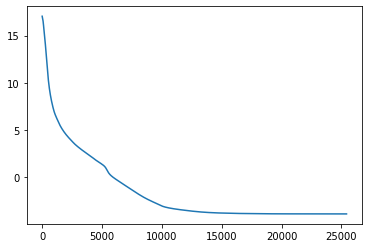

In [ ]:
new = Net_auto_ln()
param = list(new.parameters())
#print(param)
basis2 = torch.clone(basis)
#basis2[basis2==0] =-1
batch = torch.clone(basis2)
#print(batch)
m = 0.1

dist = new.optimize(batch)
plt.plot(dist[1:])

print('exact solution ={}'.format(c))
psi = new(basis).prod(dim = 1).reshape(1,16)
res = torch.matmul(psi, torch.matmul(H, torch.transpose(psi, 0, 1)))
print('ML solution ={}'.format(res))
#print('exact solution ={}'.format(new.loss_classic(new(basis).prod(dim = 1))))

In [9]:
class MaskedLinear_MADE(nn.Linear):
    def __init__(self, in_channels, out_channels, n, bias, exclusive):
        super(MaskedLinear_MADE, self).__init__(in_channels * n , out_channels * n , bias) #in n == 1 then returns nan
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.n = n
        self.exclusive = exclusive
        #self.n = 1
        
        self.register_buffer('mask', torch.ones([self.n] * 2))
        if self.exclusive:
            self.mask = 1 - torch.triu(self.mask)
        else:
            self.mask = torch.tril(self.mask)
        #print(self.mask)
        self.mask = torch.cat([self.mask] * in_channels, dim=1)
        self.mask = torch.cat([self.mask] * out_channels, dim=0)
        #print(self.mask)
        self.weight.data *= self.mask

        # Correction to Xavier initialization
        self.weight.data *= torch.sqrt(self.mask.numel() / self.mask.sum())

    def forward(self, x):
        return nn.functional.linear(x, self.mask * self.weight, self.bias)

    def extra_repr(self):
        return (super(MaskedLinear, self).extra_repr() +
                ', exclusive={exclusive}'.format(**self.__dict__))



In [10]:
class MyLinearLayer(nn.Module):
    """ Custom Linear layer but mimics a standard linear layer """
    def __init__(self, size_in, size_out, n, bias, exclusive):
        super().__init__()
        
        self.size_in = size_in 
        self.size_out = size_out 
        self.n = n
        self.is_bias = bias
        self.exclusive = exclusive
        
        weights = torch.Tensor(size_out*n, size_in*n)
        self.weights = nn.Parameter(weights)  # nn.Parameter is a Tensor that's a module parameter.
        # initialize weights and biases
        nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5)) # weight init
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weights)
        bound = 1 / math.sqrt(fan_in)
        
        if self.is_bias:
            bias = torch.Tensor(size_out*n)
            self.bias = nn.Parameter(bias)
            nn.init.uniform_(self.bias, -bound, bound)  # bias init

        self.register_buffer('mask', torch.ones([self.n] * 2))
        #self.mask = torch.ones([self.n] * 2)
        
        if self.exclusive:
            self.mask = 1 - torch.triu(self.mask)
        else:
            self.mask = torch.tril(self.mask)
        #print(self.mask)
        self.mask = torch.cat([self.mask] * size_in, dim=1)
        self.mask = torch.cat([self.mask] * size_out, dim=0)
        
        self.weights.data *= self.mask
        #print(self.mask, self.weights.data,)
        
        
    def forward(self, x):
        self.weights.data *= self.mask
        w_times_x= torch.mm(x, self.weights.t())
        if self.is_bias:
            res = torch.add(w_times_x, self.bias)  
        else:
            res = w_times_x
        return res  # w times x + b

In [11]:
a = MyLinearLayer(1,3,3,True,True)

print(a.weights, a.mask, a.bias)

Parameter containing:
tensor([[-0.3584,  0.0880,  0.5426],
        [ 0.0812,  0.5190,  0.4257],
        [ 0.1285,  0.4111,  0.4203],
        [-0.1087,  0.0530, -0.2287],
        [-0.1799, -0.1434,  0.1796],
        [ 0.3080, -0.0054, -0.4814],
        [ 0.3613,  0.1758,  0.3030],
        [-0.2015,  0.3411, -0.1854],
        [ 0.2532, -0.4250,  0.2759]], requires_grad=True) tensor([[0., 0., 0.],
        [1., 0., 0.],
        [1., 1., 0.],
        [0., 0., 0.],
        [1., 0., 0.],
        [1., 1., 0.],
        [0., 0., 0.],
        [1., 0., 0.],
        [1., 1., 0.]]) Parameter containing:
tensor([ 0.3647, -0.1195, -0.4403,  0.0638,  0.3580,  0.0985, -0.5034,  0.3140,
        -0.4595], requires_grad=True)


In [35]:
class MY_MADE_ln(nn.Module):
    
    lr = 0.005
    N_epochs = 100000
    
    def __init__(self):
        super(MY_MADE_ln,self).__init__()
        #self.Linear0 = MaskedLinear_MADE(1, 10, number_of_qubits, bias = False, exclusive=False)
        #self.Linear1 = MaskedLinear_MADE(10, 10, number_of_qubits, bias = False, exclusive=False)
        #self.Linear2 = MaskedLinear_MADE(10, 1, number_of_qubits, bias = False, exclusive=False)
        #self.Linear0 = nn.Linear(number_of_qubits, 10*number_of_qubits)
        #self.Linear1 = nn.Linear(10*number_of_qubits, 20*number_of_qubits)
        #self.Linear2 = nn.Linear(20*number_of_qubits, number_of_qubits)
        self.Linear0 = MyLinearLayer(1,10,number_of_qubits, True, True)
        self.Linear1 = MyLinearLayer(10,20,number_of_qubits, True, False)
        self.Linear2 = MyLinearLayer(20,1,number_of_qubits, True, False)

        self.Linear4 = nn.Linear(number_of_qubits, 50)
        self.Linear5 = nn.Linear(50,1)
        self.Linear6 = nn.Linear(number_of_qubits,2)
        self.epsilon = 0.00001
         
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.bn0 = nn.BatchNorm1d(10*number_of_qubits)
        self.bn1 = nn.BatchNorm1d(20*number_of_qubits)
        self.softmax = nn.Softmax(dim = 1)
        self.lnsigmoid = nn.LogSigmoid()
        
    def forward(self,a):
        x = self.Linear0(a)
        x = self.sigmoid(x)
        #x = self.tanh(x)
        #x = self.bn0(x)
        

        x = self.Linear1(x)
        x = self.tanh(x)
        #x = self.sigmoid(x)
        #x = self.bn1(x)
        

        x = self.Linear2(x)
        #x[a == 1] = self.sigmoid(x[a == 1])
        #x[a == 0] = 1 - self.sigmoid(x[a == 0])
        x[a == 1] = self.tanh(x[a == 1])
        x[a == 0] = torch.sqrt(1 - self.tanh(x[a == 0])**2)
        #x[a == 1] = self.lnsigmoid(x[a == 1])
        #x[a == 0] = torch.log(torch.abs(1 - self.sigmoid(x[a==0])))
        

        y = self.Linear4(a)
        y = self.sigmoid(y)
        y = self.Linear5(y)
        y = self.sigmoid(y)*2*math.pi

        return x,y
    
    
    def loss(self,batch):
        out, num= torch.unique(batch, return_counts = True,dim = 0)
        psi,phase = new(out)
        #print(psi)
        psi = psi.prod(dim =1)
        #psi = torch.sqrt(psi)
        #print(psi.norm(), 'norma')
        #psi = psi/psi.norm()
        #
        #psi = psi.sum(dim = 1)
        #psi = torch.exp(psi)
        #psi = torch.sqrt(psi)
        #psi = psi/(psi.norm()+self.epsilon)
        print(psi.norm())

        #psi_real = psi *torch.cos(phase.view(psi.shape[0])) 
        #psi_imag = psi *torch.sin(phase.view(psi.shape[0]))

        

        #print((psi**2 > 0).prod())
        M = matrix(out)
        #E = torch.matmul(torch.transpose(psi_real.view(out.shape[0],1), 0, 1), torch.matmul(M, psi_real)) + torch.matmul(torch.transpose(psi_imag.view(out.shape[0],1), 0, 1), torch.matmul(M, psi_imag))
        #print(torch.matmul(torch.transpose(psi_real.view(out.shape[0],1), 0, 1), torch.matmul(M, psi_imag)) - torch.matmul(torch.transpose(psi_imag.view(out.shape[0],1), 0, 1), torch.matmul(M, psi_real)))
        E = torch.matmul(torch.transpose(psi.view(out.shape[0],1), 0, 1), torch.matmul(M, psi))
        return E

    
    def optimize(self,inp):
        optimizer = torch.optim.Adam(self.parameters(), lr = self.lr, betas=(0.9, 0.999))###
        #optimizer = torch.optim.SGD(self.parameters(), self.lr, momentum= 0.9) 
        distance = []
        count = 0
        previous = 0
        #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5000,20000], gamma=0.1)
        for i in tqdm(range(self.N_epochs)): #tqdm показывет процесс выполенения в процентах
            optimizer.zero_grad()
            count += 1
            
            loss_curr = self.loss(inp)
            #scheduler.step()
            print(loss_curr)

            if math.isnan(loss_curr):
                break
                
            if i == self.N_epochs - 1:
                print(loss_curr)
            
            loss_curr.backward()
            
            #nn.utils.clip_grad_value_(new.parameters(), clip_value=1.0)
            optimizer.step() # parameter update
            distance.append(loss_curr.view(1).detach().cpu().numpy())# To stop a tensor from tracking history, you can call .detach() 
            #to detach it from the computation history, and to prevent future computation from being tracked.
            
            #print(distance[-1] - previous)
            previous = distance[-1]
            if count == 1000:
                clear_output()
                plt.plot(distance)
                plt.show()
                print(loss_curr)
                #print(new(inp))
                print('Epoch-{0} lr: {1}'.format(i, optimizer.param_groups[0]['lr']))
                count = 0
        return distance   












  0%|          | 0/100000 [00:00<?, ?it/s]










  0%|          | 2/100000 [00:00<2:29:49, 11.12it/s]

tensor(1.0000, device='cuda:0', grad_fn=<CopyBackwards>)
tensor([56.1781], device='cuda:0', grad_fn=<MvBackward>)
tensor(1., device='cuda:0', grad_fn=<CopyBackwards>)
tensor([55.9403], device='cuda:0', grad_fn=<MvBackward>)
tensor(1.0000, device='cuda:0', grad_fn=<CopyBackwards>)













  0%|          | 4/100000 [00:00<2:26:41, 11.36it/s]

tensor([55.6909], device='cuda:0', grad_fn=<MvBackward>)
tensor(1., device='cuda:0', grad_fn=<CopyBackwards>)
tensor([55.4297], device='cuda:0', grad_fn=<MvBackward>)
tensor(1., device='cuda:0', grad_fn=<CopyBackwards>)
tensor([55.1565], device='cuda:0', grad_fn=<MvBackward>)
tensor(1., device='cuda:0', grad_fn=<CopyBackwards>)













  0%|          | 6/100000 [00:00<2:21:14, 11.80it/s]










  0%|          | 8/100000 [00:00<2:16:35, 12.20it/s]

...

tensor([-0.6226], device='cuda:0', grad_fn=<MvBackward>)
tensor(1., device='cuda:0', grad_fn=<CopyBackwards>)
tensor([-0.6246], device='cuda:0', grad_fn=<MvBackward>)
tensor(1., device='cuda:0', grad_fn=<CopyBackwards>)
tensor([-0.6266], device='cuda:0', grad_fn=<MvBackward>)
tensor(1.0000, device='cuda:0', grad_fn=<CopyBackwards>)
tensor([-0.6286], device='cuda:0', grad_fn=<MvBackward>)


  1%|          | 806/100000 [00:55<1:52:12, 14.73it/s]










  1%|          | 808/100000 [00:55<1:52:11, 14.74it/s]

tensor(1.0000, device='cuda:0', grad_fn=<CopyBackwards>)
tensor([-0.6305], device='cuda:0', grad_fn=<MvBackward>)
tensor(1., device='cuda:0', grad_fn=<CopyBackwards>)
tensor([-0.6324], device='cuda:0', grad_fn=<MvBackward>)
tensor(1.0000, device='cuda:0', grad_fn=<CopyBackwards>)
tensor([-0.6344], device='cuda:0', grad_fn=<MvBackward>)
tensor(1.0000, device='cuda:0', grad_fn=<CopyBackwards>)













  1%|          | 810/100000 [00:55<1:52:21, 14.71it/s]










  1%|          | 812/100000 [00:55<1:52:03, 14.75it/s]

tensor([-0.6363], device='cuda:0', grad_fn=<MvBackward>)
tensor(1., device='cuda:0', grad_fn=<CopyBackwards>)
tensor([-0.6381], device='cuda:0', grad_fn=<MvBackward>)
tensor(1., device='cuda:0', grad_fn=<CopyBackwards>)
tensor([-0.6400], device='cuda:0', grad_fn=<MvBackward>)
tensor(1., device='cuda:0', grad_fn=<CopyBackwards>)
tensor([-0.6419], device='cuda:0', grad_fn=<MvBackward>)
tensor(nan, device='cuda:0', grad_fn=<CopyBackwards>)
tensor([nan], device='cuda:0', grad_fn=<MvBackward>)


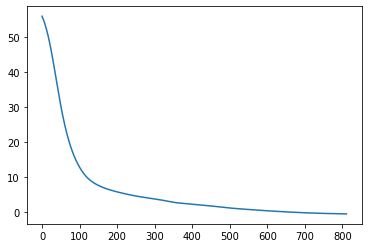

In [36]:
new = MY_MADE_ln()
new.to(device)

basis2 = torch.clone(basis)
batch = torch.clone(basis2)
batch = batch.to(device)
#print(batch)
m = 0.1

dist = new.optimize(batch)
plt.plot(dist[1:])
